# Data Augmentation

In [1]:
# Experiments on Graph Extraction and Balancing from RTMLPA.csv
# ------------------------------------------------------------

import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.nn import knn_graph
import os
import random
from collections import defaultdict, Counter

/Users/dennisamematekpor/Downloads/bdata/projects/ProjetM1/.venv/lib/python3.9/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: dlopen(/Users/dennisamematekpor/Downloads/bdata/projects/ProjetM1/.venv/lib/python3.9/site-packages/libpyg.so, 0x0006): Library not loaded: /Library/Frameworks/Python.framework/Versions/3.9/Python
  Referenced from: <060574F3-7207-3B1B-B3B2-CB39F1F5BC6E> /Users/dennisamematekpor/Downloads/bdata/projects/ProjetM1/.venv/lib/python3.9/site-packages/libpyg.so
  Reason: tried: '/Library/Frameworks/Python.framework/Versions/3.9/Python' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/Python.framework/Versions/3.9/Python' (no such file), '/Library/Frameworks/Python.framework/Versions/3.9/Python' (no such file)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/Users/dennisamematekpor/Downloads/bdata/projects/ProjetM1/.venv/lib/python3.9/site-pa

In [2]:
# === Shared Setup ===

def load_all_graphs_from_patient_dirs(label_dict):
    base_dir = "./cluster"
    all_graphs = []
    for patient_id in label_dict:
        patient_folder = os.path.join(base_dir, f"{str(patient_id).zfill(3)}")
        if os.path.isdir(patient_folder):
            for f in os.listdir(patient_folder):
                if f.endswith(".csv"):
                    try:
                        df_nuc = pd.read_csv(os.path.join(patient_folder, f))
                        x = torch.tensor(df_nuc[[
                            'dist_centr', 'diameter', 'area', 'convexity', 'eccentricity',
                            'elongation', 'circularity', 'compactness', 'solidity',
                            'longAxis', 'shortAxis', 'ellipseAngle',
                            'color_dist_0', 'color_dist_1', 'color_dist_2']].values, dtype=torch.float)
                        k = min(10, len(x) - 1) if len(x) > 1 else 1
                        edge_index = knn_graph(x, k=k)
                        y = torch.tensor(label_dict[patient_id])
                        all_graphs.append(Data(x=x, edge_index=edge_index, y=y))
                    except Exception as e:
                        print(f"Skipping {f} for patient {patient_id} due to error: {e}")
    return all_graphs

In [3]:
# === Augmentation Functions ===

def perturb_features(data, noise_std=0.01):
    data_aug = data.__class__.from_dict(data.to_dict())
    noise = torch.randn_like(data.x) * noise_std
    data_aug.x = data.x + noise
    return data_aug

def drop_edges(data, drop_prob=0.2):
    from torch_geometric.utils import dropout_edge
    edge_index, _ = dropout_edge(data.edge_index, p=drop_prob, force_undirected=True)
    return Data(x=data.x, edge_index=edge_index, y=data.y)

def drop_nodes(data, drop_prob=0.1):
    node_mask = torch.rand(data.num_nodes) >= drop_prob
    x = data.x[node_mask]
    old_to_new = -torch.ones(data.num_nodes, dtype=torch.long)
    old_to_new[node_mask] = torch.arange(node_mask.sum())
    src, dst = data.edge_index
    keep_edge = node_mask[src] & node_mask[dst]
    edge_index = data.edge_index[:, keep_edge]
    edge_index = old_to_new[edge_index]
    return Data(x=x, edge_index=edge_index, y=data.y)

augment_fns = [perturb_features, drop_edges, drop_nodes]

def visualize_distribution(graphs, title):
    label_count = Counter([int(g.y.item()) for g in graphs])
    plt.bar(['ABC (0)', 'GCB (1)'], [label_count[0], label_count[1]], color=['skyblue', 'salmon'])
    plt.title(title)
    plt.ylabel("Number of Graphs")
    plt.tight_layout()
    plt.show()

In [4]:
# === Load RTMLPA and Prepare Label Dict ===

df = pd.read_csv("RTMLPA.csv")
df = df[df['label'].isin(['ABC', 'GCB'])]
df['label_num'] = df['label'].map({'ABC': 0, 'GCB': 1})
label_dict = dict(zip(df['patient_id'], df['label_num']))

# === Base Graphs Shared by All Experiments ===
base_graphs = load_all_graphs_from_patient_dirs(label_dict)

### Experiment 1

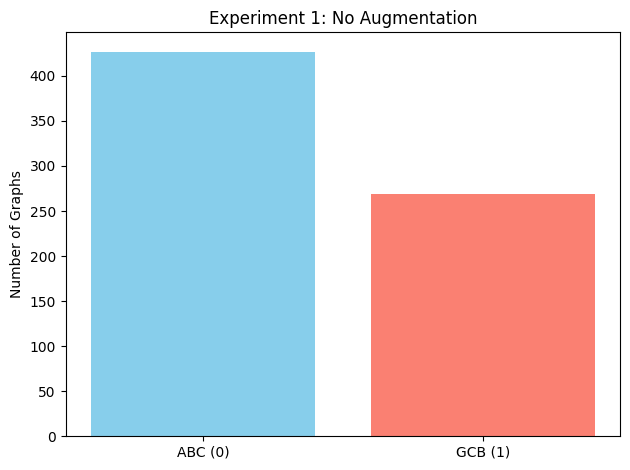

In [5]:
# === Experiment 1: No balancing or augmentation ===

data_graphs_exp1 = base_graphs.copy()
visualize_distribution(data_graphs_exp1, "Experiment 1: No Augmentation")

### Experiment 2

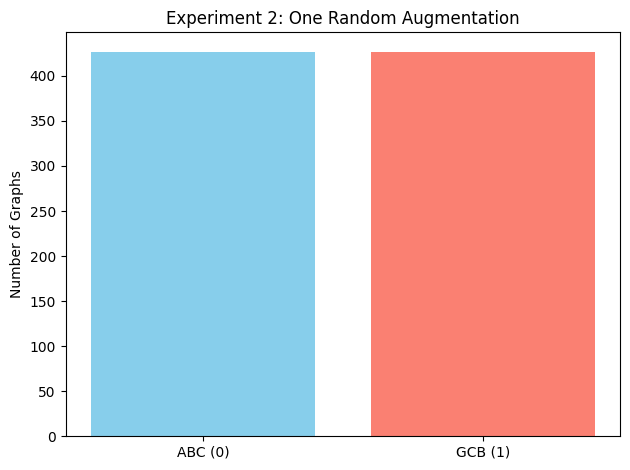

In [6]:
# === Experiment 2: One Random Augmentation to Balance ===

graph_by_class = defaultdict(list)
for g in base_graphs:
    graph_by_class[int(g.y.item())].append(g)
max_size = max(len(c) for c in graph_by_class.values())

exp2_graphs = []
for label in [0, 1]:
    graphs = graph_by_class[label]
    augmented = graphs.copy()
    while len(augmented) < max_size:
        g = random.choice(graphs)
        aug_fn = random.choice(augment_fns)
        augmented.append(aug_fn(g))
    exp2_graphs.extend(augmented)

visualize_distribution(exp2_graphs, "Experiment 2: One Random Augmentation")

### Experiment 3

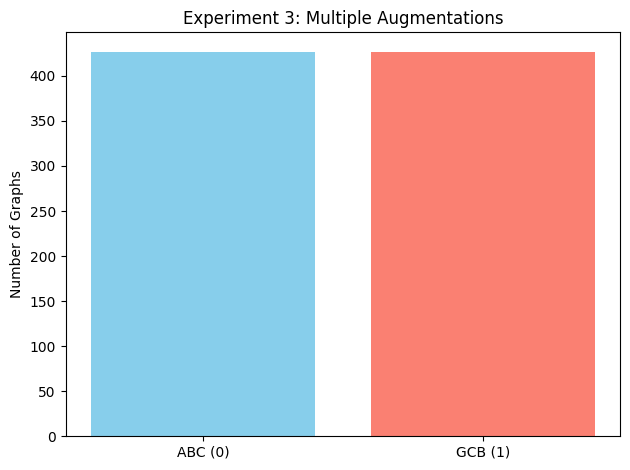

In [7]:
# === Experiment 3: Multiple Augmentations to Balance ===

exp3_graphs = []
for label in [0, 1]:
    graphs = graph_by_class[label]
    augmented = graphs.copy()
    while len(augmented) < max_size:
        g = random.choice(graphs)
        g_aug = g
        for fn in random.sample(augment_fns, k=random.randint(1, len(augment_fns))):
            g_aug = fn(g_aug)
        augmented.append(g_aug)
    exp3_graphs.extend(augmented)

visualize_distribution(exp3_graphs, "Experiment 3: Multiple Augmentations")

### Experiment 4

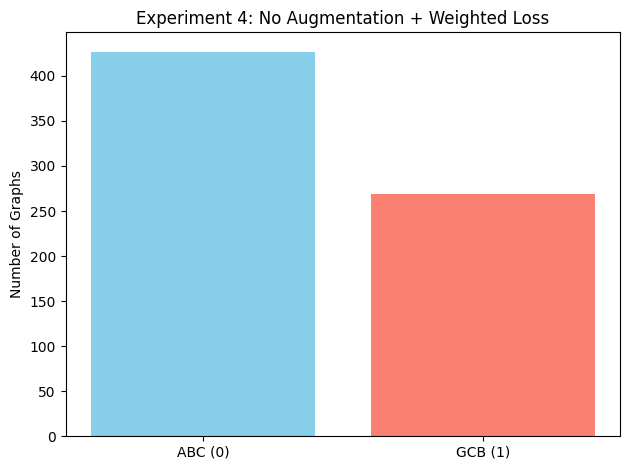

Recommended class weights: [1.6299766302108765, 2.5873606204986572]


In [8]:
# === Experiment 4: Weighted Loss Without Augmentation ===

data_graphs_exp4 = base_graphs.copy()
label_count_exp4 = Counter([int(g.y.item()) for g in data_graphs_exp4])
total = sum(label_count_exp4.values())
weights = torch.tensor([
    total / label_count_exp4[0],
    total / label_count_exp4[1]
], dtype=torch.float)

visualize_distribution(data_graphs_exp4, "Experiment 4: No Augmentation + Weighted Loss")
print("Recommended class weights:", weights.tolist())